# Complementary Macroeconomics

# 8th Session

# AR and VAR Processes: Simulation & Analysis

In [242]:
import numpy as np
import matplotlib.pyplot as plt

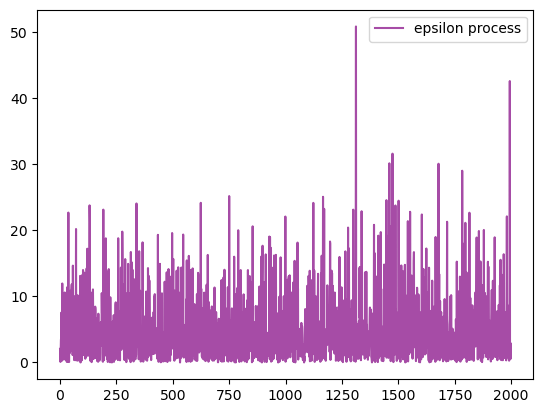

In [288]:
epsilon = np.random.gamma(1, 5, obs)

plt.plot(epsilon, color = 'purple', label = 'epsilon process', alpha = 0.7)
plt.legend()
plt.show()

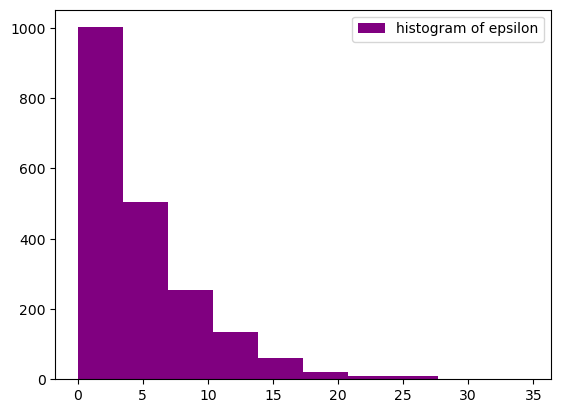

In [286]:
plt.hist(epsilon, color = 'purple', label = 'histogram of epsilon')
plt.legend()
plt.show()

## About for-loop

In [313]:
p = 1
print(p)

1


In [315]:
for q in range(1, 5):
    print(q)

1
2
3
4


In [317]:
print(q)

4


In [331]:
random_number = np.random.normal(0, 1, 5)
print(random_number)

[-0.00154355 -0.76202491 -0.53437192  0.44051298 -1.3240416 ]


### This loop generates an array of five random numbers from a normal distribution, then prints the square of that array four times.

In [333]:
for i in range(1, 5):
    print(random_number ** 2)

[2.38253169e-06 5.80681968e-01 2.85553350e-01 1.94051682e-01
 1.75308617e+00]
[2.38253169e-06 5.80681968e-01 2.85553350e-01 1.94051682e-01
 1.75308617e+00]
[2.38253169e-06 5.80681968e-01 2.85553350e-01 1.94051682e-01
 1.75308617e+00]
[2.38253169e-06 5.80681968e-01 2.85553350e-01 1.94051682e-01
 1.75308617e+00]


### This loop iterates from 1 to 4, calculates the square of each corresponding element in random_number, and prints the result.

In [337]:
for i in range(1, 5):
    variable1 = random_number[i] **2
    print(variable1)

0.5806819675519587
0.2855533496725898
0.19405168227221767
1.7530861656081649


### This loop iterates from 1 to 4, computes the square of the previous element in random_number, adds the current element, and prints the result.

In [341]:
for i in range(1, 5):
    o = random_number[i-1] ** 2 + random_number[i]
    print(o)

-0.7620201476212147
0.6269847521838527
0.44480154455557314
-0.9321507022704077


# An AR simulation with a shock

In [530]:
phi = 0.9
obs = 200
epsilon1 = np.random.normal(0, 1, obs)

AR_obs = np.zeros(obs)

AR_obs[0:5]

array([0., 0., 0., 0., 0.])

### $AR_1 = \phi AR_0 + \epsilon_1$

In [533]:
for points in range(1, obs):
    AR_obs[points] = phi * AR_obs[points -1] + epsilon1[points]

AR_obs[0: 5]

array([ 0.        ,  0.41731882, -0.56878155, -0.27380025, -1.65238314])

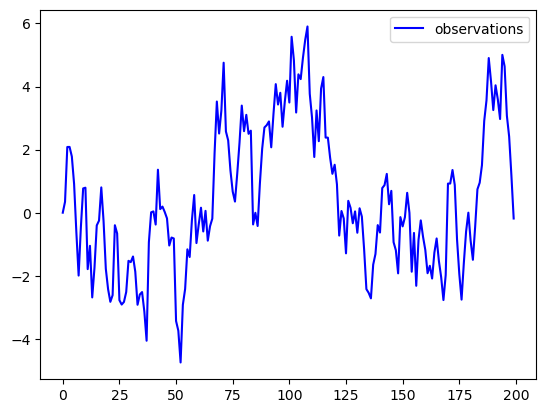

In [394]:
plt.plot(AR_obs, label = "observations", color = "blue")
plt.legend()
plt.show()

## With a shock at 20th period

In [396]:
phi = 0.9
obs = 200
epsilon = np.random.normal(0, 1, obs)

AR_obs = np.zeros(obs)

AR_obs[0:5]
shock_time = 20

epsilon[shock_time] 

-0.3534634496162708

In [398]:
shock_time = 20
epsilon[shock_time] = epsilon[shock_time] * 10
#epsilon[shock_time] *= 10

In [400]:
epsilon[shock_time] 

-3.534634496162708

#### augmented variable assignment

In [402]:
a = 50
a + 10

60

In [404]:
print(a)

50


In [362]:
a = a + 10
print(a)

60


In [364]:
a += 10
print(a) #expeting 70

70


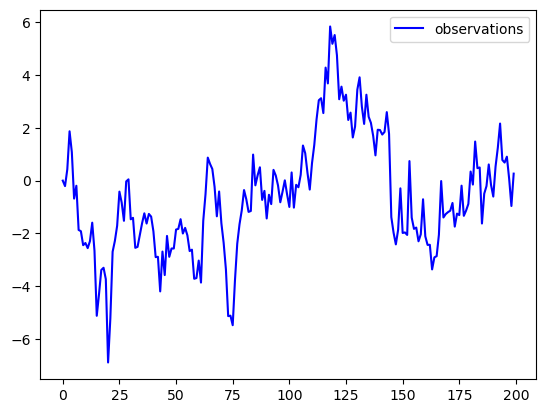

In [406]:
AR_obs_with_shock = np.zeros(obs)

for t in range(1, obs):
    AR_obs_with_shock[t] = phi * AR_obs_with_shock[t-1] + epsilon[t]

plt.plot(AR_obs_with_shock, label = "observations", color = "blue")
plt.legend()
plt.show()

## Using np.random.seed() for comparing

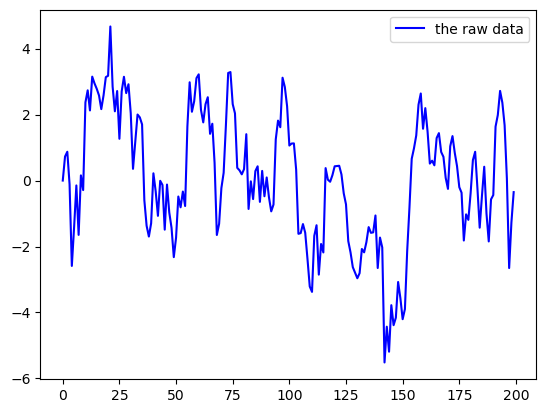

In [420]:
np.random.seed(6)

phi = 0.9
obs = 200
epsilon2 = np.random.normal(0, 1, obs)

AR_obs = np.zeros(obs)

for points in range(1, obs):
    AR_obs[points] = phi * AR_obs[points -1] + epsilon2[points]

shock_time = 20
epsilon2[shock_time] = epsilon2[shock_time] * 10

for t in range(1, obs):
    AR_obs_with_shock[t] = phi * AR_obs_with_shock[t-1] + epsilon2[t]

plt.plot(AR_obs, color = "blue", label = "the raw data")
plt.legend()
plt.show()

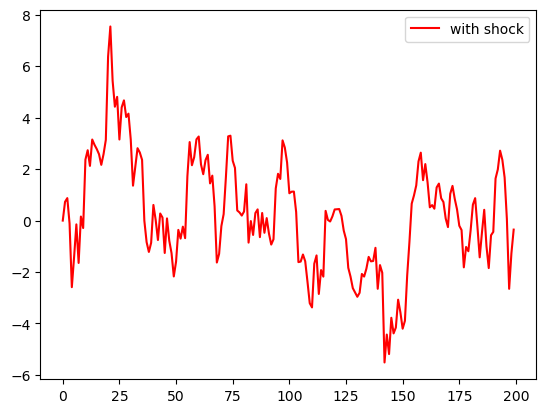

In [422]:
plt.plot(AR_obs_with_shock, color = "red",label = 'with shock')
plt.legend()
plt.show()

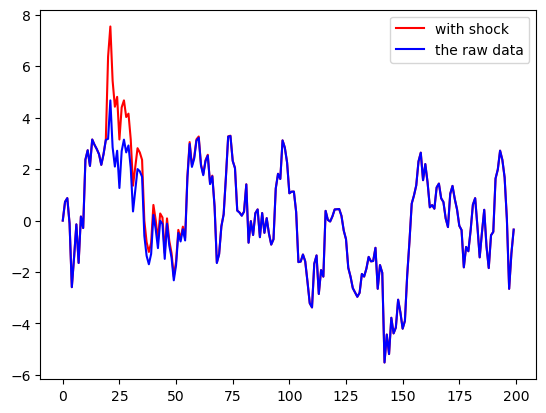

In [424]:
plt.plot(AR_obs_with_shock, color = "red",label = 'with shock')
plt.plot(AR_obs, color = "blue", label = "the raw data")
plt.legend()
plt.show()

## Explosive AR

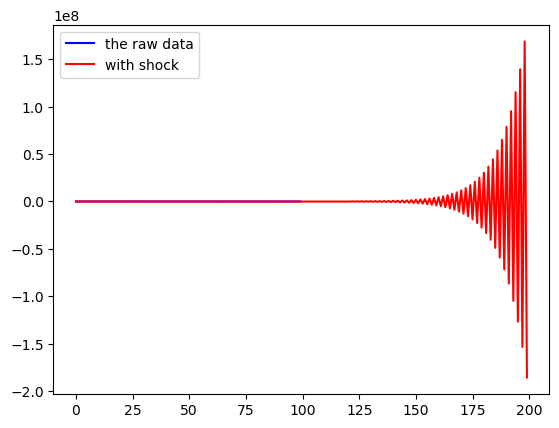

In [442]:
np.random.seed(6)

phi = -1.1
obs = 100
epsilon3 = np.random.normal(0, 1, obs)

AR_obs = np.zeros(obs)

for points in range(1, obs):
    AR_obs[points] = phi * AR_obs[points -1] + epsilon3[points]

shock_time = 20
epsilon3[shock_time] = epsilon3[shock_time] * 10

for t in range(1, obs):
    AR_obs_with_shock[t] = phi * AR_obs_with_shock[t-1] + epsilon3[t]

plt.plot(AR_obs, color = "blue", label = "the raw data")
plt.plot(AR_obs_with_shock, color = "red",label = 'with shock')
plt.legend()
plt.show()

# Vector Autoregressive

## VAR(1)

### $Y_{1t} = \beta_{01} + \beta_{11} Y_{1t-1} + \beta_{12} Y_{2t-1} + \epsilon_{1t}$
### $Y_{2t} = \beta_{01} + \beta_{21} Y_{1t-1} + \beta_{22} Y_{2t-1} + \epsilon_{2t}$

In [444]:
a, b , c = 1, 2, 3
print(a)
print(b)
print(c)

1
2
3


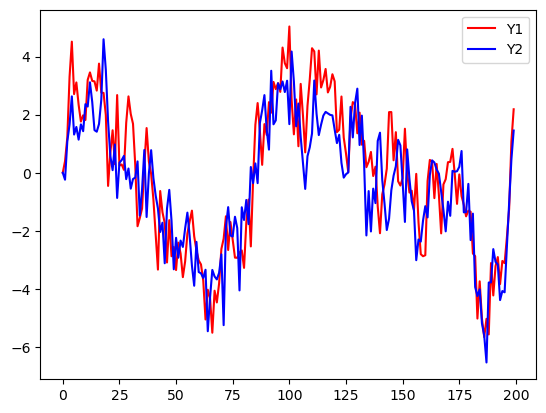

In [474]:
np.random.seed(0)

num = 200

Y1 = np.zeros(num)
Y2 = np.zeros(num)

beta_01, beta_02 = 0, 0
beta_11, beta_12 = 0.7, 0.2
beta_21, beta_22 = 0.3, 0.6

epsilon_1t = np.random.normal(0, 1, num)
epsilon_2t = np.random.normal(0, 1, num)

for t in range(1, num):
    Y1[t] = beta_01 + beta_11 * Y1[t - 1] + beta_12 * Y2[t-1] + epsilon_1t[t]
    Y2[t] = beta_02 + beta_21 * Y1[t - 1] + beta_22 * Y2[t-1] + epsilon_2t[t]

plt.plot(Y1, label = 'Y1', color = "red")
plt.plot(Y2, label = 'Y2', color = "blue")
plt.legend()
plt.show()

## Impulse response function (IRF)

- By default, irf() applies a unit shock (1 standard deviation).

## Matrices in Python

In [477]:
np.array([1, 2, 3])

array([1, 2, 3])

In [481]:
np.array([[1, 2, 3], [1, 2, 3], [1, 2, 3]])

array([[1, 2, 3],
       [1, 2, 3],
       [1, 2, 3]])

In [483]:
h = np.array([[1], [2], [3]])
j = np.array([[5], [7], [8]])

print(h)
print(j)

[[1]
 [2]
 [3]]
[[5]
 [7]
 [8]]


In [485]:
np.column_stack((h,j))

array([[1, 5],
       [2, 7],
       [3, 8]])

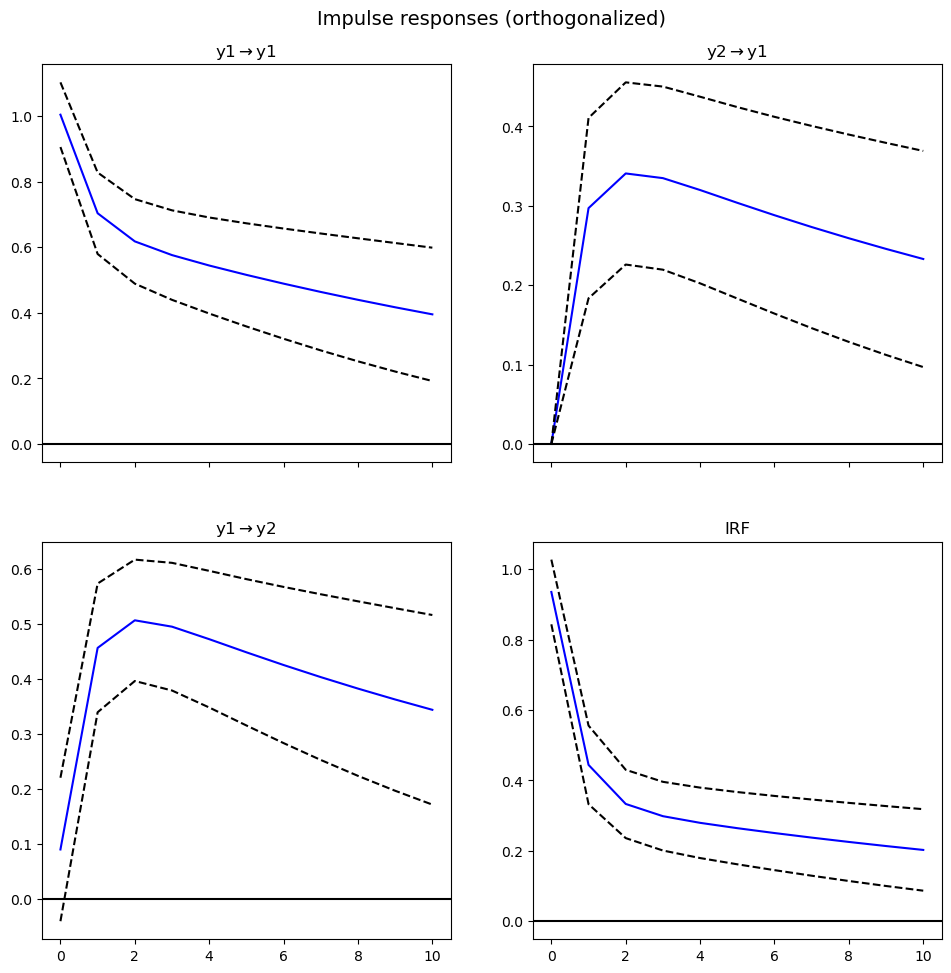

In [491]:
from statsmodels.tsa.api import VAR

data = np.column_stack((Y1, Y2))

model = VAR(data)
results = model.fit(1)

irf = results.irf(10)
#print(irf.irfs)
irf.plot(orth = True)
plt.title('IRF')
plt.show()

### Multiply the IRF by your desired standard deviation.

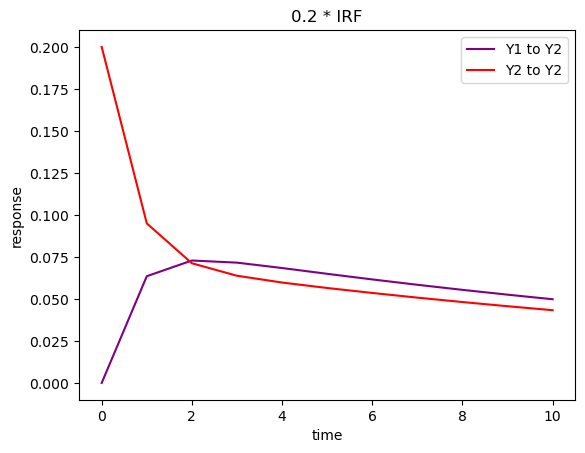

In [515]:
irf1 = results.irf(10)

shock_std = 0.2
custom_irf = irf1.irfs * shock_std

plt.plot(custom_irf[:, 0, 1], label = "Y1 to Y2", color = "purple")
plt.plot(custom_irf[:, 1, 1], label = "Y2 to Y2", color = "red")

plt.title("0.2 * IRF")
plt.xlabel("time")
plt.ylabel("response")
plt.legend()
plt.show()

# Exercises

## 1. Simulate two similar stationary AR(2) processes—one without shocks and one with a shock at the 37th period—then:

### - compare their plots.

### - Implement ACF and PACF on each of them.

### - Increase their roots so they become non-stationary then Re-apply ACF and PACF.

## 2. Write a function that creates an AR(1) process and plots the series.

## 3. Simulate an AR(1) process and then fit an AR(1) model to your simulated series.

#### Hint: Fit an AR(1) model using AutoReg from statsmodels, specifying lags=1. After fitting the model, examine its parameters and summary to understand the estimated autoregressive coefficient and intercept.

## 4. Calculate inflation using the GDP deflator and plot it alongside the results from the first exercise in the third session notebook.